# Fast Fourier Transform: Finding Frequencies Fast

The Fourier Transform takes a signal in time and reveals the frequencies inside it.

Fourier analysis began in the study of heat, but the FFT made frequency analysis practical at digital scale. Modern audio, image compression, medical imaging, radio, seismology, astronomy, and numerical simulation all depend on quickly moving between signals and their frequency recipes.

The Fast Fourier Transform, or FFT, is the divide-and-conquer version. Instead of checking every frequency the slow way, it splits the signal into even and odd samples, solves smaller transforms, then recombines them with rotating complex numbers.

<details>
<summary>Big idea</summary>

A messy waveform can be built from simple sine waves. FFT lets us reverse-engineer that recipe quickly.

</details>

## 1. Mental Model

A time signal answers: **what is happening at each moment?**

A frequency spectrum answers: **which rhythms are present?**

The FFT works because a length-$N$ transform can be split into two length-$N/2$ transforms:

- one for the even-indexed samples,
- one for the odd-indexed samples,
- then both are recombined with twiddle factors.

<details>
<summary>Twiddle factor hint</summary>

A twiddle factor is a complex rotation: $e^{-2\pi i k/N}$. It lines up the odd half of the signal before adding and subtracting it from the even half.

</details>

## 2. Build the Objects

We will build a small FFT lab:

- `SignalComponent` stores one hidden sine-wave ingredient.
- `SampledSignal` stores time samples and signal values.
- `FFTSnapshot` records the recursion tree.
- `FFTResult` stores frequencies, magnitudes, phases, and reconstruction error.
- `recursive_fft` implements Cooley-Tukey FFT from scratch.

<details>
<summary>Implementation hint</summary>

This simple FFT expects the signal length to be a power of two. That keeps the divide-and-conquer split clean at every recursion level.

</details>

**Object model.** Define `SignalComponent`, the named objects used by the next examples.


In [ ]:
from dataclasses import dataclass

import matplotlib.pyplot as plt

import numpy as np

@dataclass(frozen=True)
class SignalComponent:
    frequency: float
    amplitude: float
    phase: float = 0.0

    def sample(self, times: np.ndarray) -> np.ndarray:
        return self.amplitude * np.sin(2 * np.pi * self.frequency * times + self.phase)


**Trace model.** Define `SampledSignal`, `FFTSnapshot`, the structure used to capture replayable algorithm state.


In [ ]:
@dataclass(frozen=True)
class SampledSignal:
    times: np.ndarray
    values: np.ndarray
    sample_rate: float
    components: tuple[SignalComponent, ...]

    @property
    def sample_count(self) -> int:
        return self.values.size

    @property
    def duration(self) -> float:
        return self.sample_count / self.sample_rate

@dataclass(frozen=True)
class FFTSnapshot:
    depth: int
    branch: str
    sample_count: int
    note: str


**Object model.** Define `FFTResult`, the named objects used by the next examples.


In [ ]:
@dataclass(frozen=True)
class FFTResult:
    frequencies: np.ndarray
    spectrum: np.ndarray
    magnitudes: np.ndarray
    phases: np.ndarray
    reconstruction_error: float
    snapshots: tuple[FFTSnapshot, ...]

    def top_frequencies(self, count: int = 5, minimum_frequency: float = 0.1) -> list[tuple[float, float]]:
        usable = self.frequencies >= minimum_frequency
        usable_indices = np.where(usable)[0]
        ranked = usable_indices[np.argsort(self.magnitudes[usable_indices])[::-1]]
        return [
            (float(self.frequencies[index]), float(self.magnitudes[index]))
            for index in ranked[:count]
        ]

def is_power_of_two(value: int) -> bool:
    return value > 0 and value & (value - 1) == 0


**Builder helper.** Define `make_signal`, which prepares reusable examples or traces.


In [ ]:
def make_signal(
    components: list[SignalComponent],
    sample_rate: float = 128.0,
    duration: float = 2.0,
    noise_scale: float = 0.0,
    seed: int = 9,
) -> SampledSignal:
    sample_count = int(sample_rate * duration)
    if not is_power_of_two(sample_count):
        raise ValueError("sample_rate * duration must produce a power-of-two sample count.")

    times = np.arange(sample_count) / sample_rate
    values = sum(component.sample(times) for component in components)

    if noise_scale > 0:
        rng = np.random.default_rng(seed)
        values = values + rng.normal(0.0, noise_scale, size=sample_count)

    return SampledSignal(times=times, values=values, sample_rate=sample_rate, components=tuple(components))


**Helper functions.** Define `recursive_fft` so the later cells stay focused on behavior.


In [ ]:
def recursive_fft(
    signal_values: np.ndarray,
    depth: int = 0,
    branch: str = "root",
    snapshots: list[FFTSnapshot] | None = None,
) -> np.ndarray:
    values = np.asarray(signal_values, dtype=complex)
    sample_count = values.size

    if not is_power_of_two(sample_count):
        raise ValueError("recursive_fft needs a power-of-two number of samples.")

    if snapshots is not None and depth <= 3:
        snapshots.append(
            FFTSnapshot(
                depth=depth,
                branch=branch,
                sample_count=sample_count,
                note="split into even and odd samples" if sample_count > 1 else "base case",
            )
        )

    if sample_count == 1:
        return values

    even_spectrum = recursive_fft(values[::2], depth + 1, f"{branch}.even", snapshots)
    odd_spectrum = recursive_fft(values[1::2], depth + 1, f"{branch}.odd", snapshots)

    half_count = sample_count // 2
    frequency_indices = np.arange(half_count)
    twiddle_factors = np.exp(-2j * np.pi * frequency_indices / sample_count)
    rotated_odd = twiddle_factors * odd_spectrum

    return np.concatenate([even_spectrum + rotated_odd, even_spectrum - rotated_odd])


**Helper functions.** Define `recursive_ifft` so the later cells stay focused on behavior.


In [ ]:
def recursive_ifft(spectrum: np.ndarray) -> np.ndarray:
    values = np.asarray(spectrum, dtype=complex)
    return np.conjugate(recursive_fft(np.conjugate(values))) / values.size


**Helper functions.** Define `analyze_signal` so the later cells stay focused on behavior.


In [ ]:
def analyze_signal(sampled_signal: SampledSignal) -> FFTResult:
    snapshots: list[FFTSnapshot] = []
    spectrum = recursive_fft(sampled_signal.values, snapshots=snapshots)
    reconstructed = recursive_ifft(spectrum).real
    reconstruction_error = float(np.max(np.abs(reconstructed - sampled_signal.values)))

    frequencies = np.fft.fftfreq(sampled_signal.sample_count, d=1 / sampled_signal.sample_rate)
    positive_mask = frequencies >= 0
    positive_frequencies = frequencies[positive_mask]
    positive_spectrum = spectrum[positive_mask]
    magnitudes = np.abs(positive_spectrum) / sampled_signal.sample_count

    if magnitudes.size > 2:
        magnitudes[1:-1] *= 2

    phases = np.angle(positive_spectrum)
    return FFTResult(
        frequencies=positive_frequencies,
        spectrum=positive_spectrum,
        magnitudes=magnitudes,
        phases=phases,
        reconstruction_error=reconstruction_error,
        snapshots=tuple(snapshots),
    )


## 3. Create a Hidden Signal

We will mix three sine waves and add a little noise.

The time plot will look like a messy waveform, but the FFT should reveal the hidden frequency recipe.

<details>
<summary>Sampling hint</summary>

A sample rate of `128 Hz` means we record 128 values per second. With 2 seconds of data, we get 256 samples, which is a power of two.

</details>

**Run the experiment.** Advance the algorithm and collect the state changes that make the behavior visible.


In [ ]:
hidden_components = [
    SignalComponent(frequency=5, amplitude=1.20, phase=0.0),
    SignalComponent(frequency=13, amplitude=0.70, phase=0.5),
    SignalComponent(frequency=27, amplitude=0.35, phase=-0.8),
]

sampled_signal = make_signal(
    components=hidden_components,
    sample_rate=128,
    duration=2,
    noise_scale=0.12,
    seed=10,
)

print(f"Sample count: {sampled_signal.sample_count}")

print(f"Duration: {sampled_signal.duration:.1f} seconds")

print(f"Sample rate: {sampled_signal.sample_rate:.0f} Hz")

print("Hidden components:")

for component in hidden_components:
    print(f"  {component.frequency:>4.0f} Hz, amplitude {component.amplitude:.2f}")

fig, ax = plt.subplots(figsize=(9, 4))

ax.plot(sampled_signal.times, sampled_signal.values, color="#2A9D8F", linewidth=1.4)

ax.set_title("Noisy time-domain signal")

ax.set_xlabel("time in seconds")


**Inspect the result.** Render the current state so the algorithm is easier to reason about.


In [ ]:
ax.set_ylabel("amplitude")

ax.grid(alpha=0.2)

plt.show()


## 4. Run the FFT

The time signal is hard to read directly. The frequency spectrum shows which sine-wave ingredients are strongest.

We will compare our recursive FFT with `numpy.fft.fft()` as a correctness check.

Max difference from NumPy FFT: 7.18e-14
Max reconstruction error from inverse FFT: 8.88e-16
Top detected frequencies:
    5.0 Hz -> magnitude 1.192
   13.0 Hz -> magnitude 0.702
   27.0 Hz -> magnitude 0.357
   58.0 Hz -> magnitude 0.033
    3.5 Hz -> magnitude 0.027
    1.0 Hz -> magnitude 0.026


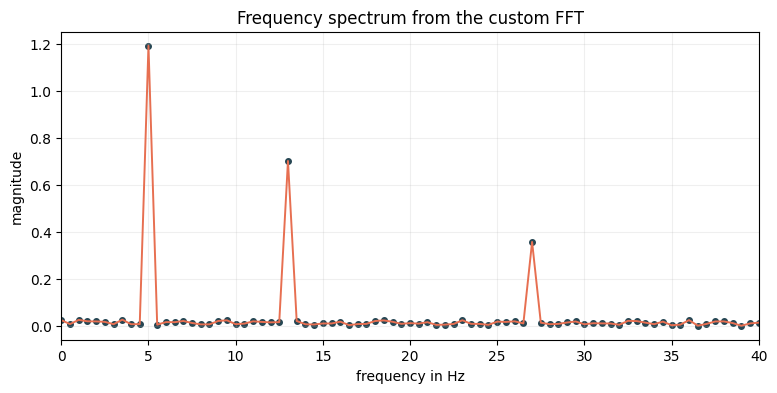

In [3]:
fft_result = analyze_signal(sampled_signal)
custom_spectrum = recursive_fft(sampled_signal.values)
numpy_spectrum = np.fft.fft(sampled_signal.values)
max_difference = np.max(np.abs(custom_spectrum - numpy_spectrum))

print(f"Max difference from NumPy FFT: {max_difference:.2e}")
print(f"Max reconstruction error from inverse FFT: {fft_result.reconstruction_error:.2e}")
print("Top detected frequencies:")
for frequency, magnitude in fft_result.top_frequencies(count=6):
    print(f"  {frequency:>5.1f} Hz -> magnitude {magnitude:.3f}")

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(fft_result.frequencies, fft_result.magnitudes, color="#E76F51", linewidth=1.4)
ax.scatter(fft_result.frequencies, fft_result.magnitudes, color="#264653", s=16)
ax.set_xlim(0, 40)
ax.set_title("Frequency spectrum from the custom FFT")
ax.set_xlabel("frequency in Hz")
ax.set_ylabel("magnitude")
ax.grid(alpha=0.2)
plt.show()

## 5. Replay the Recursion

The FFT keeps cutting the signal in half: root, even, odd, then even-of-even, odd-of-even, and so on.

We only record the top few recursion levels so the replay stays readable.

In [4]:
class FFTReplay:
    def __init__(self, snapshots: tuple[FFTSnapshot, ...]):
        self.snapshots = snapshots

    def show(self) -> None:
        for snapshot in self.snapshots:
            indent = "  " * snapshot.depth
            print(
                f"{indent}{snapshot.branch:<24} "
                f"samples={snapshot.sample_count:<3} | {snapshot.note}"
            )


FFTReplay(fft_result.snapshots).show()

root                     samples=256 | split into even and odd samples
  root.even                samples=128 | split into even and odd samples
    root.even.even           samples=64  | split into even and odd samples
      root.even.even.even      samples=32  | split into even and odd samples
      root.even.even.odd       samples=32  | split into even and odd samples
    root.even.odd            samples=64  | split into even and odd samples
      root.even.odd.even       samples=32  | split into even and odd samples
      root.even.odd.odd        samples=32  | split into even and odd samples
  root.odd                 samples=128 | split into even and odd samples
    root.odd.even            samples=64  | split into even and odd samples
      root.odd.even.even       samples=32  | split into even and odd samples
      root.odd.even.odd        samples=32  | split into even and odd samples
    root.odd.odd             samples=64  | split into even and odd samples
      root.odd.odd.ev

## 6. Why It Is Fast

The slow Discrete Fourier Transform compares every time sample with every frequency:

$$
O(N^2)
$$

The FFT reuses smaller transforms:

$$
O(N\log_2 N)
$$

That difference is why FFT is everywhere: audio, images, compression, radar, medical imaging, and scientific computing.

**Helper functions.** Define `slow_dft` so the later cells stay focused on behavior.


In [ ]:
def slow_dft(signal_values: np.ndarray) -> np.ndarray:
    values = np.asarray(signal_values, dtype=complex)
    sample_count = values.size
    output = np.zeros(sample_count, dtype=complex)

    for frequency_index in range(sample_count):
        total = 0j
        for time_index, value in enumerate(values):
            rotation = np.exp(-2j * np.pi * frequency_index * time_index / sample_count)
            total += value * rotation
        output[frequency_index] = total

    return output

small_signal = sampled_signal.values[:32]

slow_spectrum = slow_dft(small_signal)

fast_spectrum = recursive_fft(small_signal)

print(f"Slow DFT vs FFT difference on 32 samples: {np.max(np.abs(slow_spectrum - fast_spectrum)):.2e}")

print()

print("samples | slow N^2 work | FFT N log2(N) work | speedup shape")

print("-" * 67)


**Run the experiment.** Advance the algorithm and collect the state changes that make the behavior visible.


In [ ]:
for sample_count in [32, 64, 128, 256, 512, 1024, 4096]:
    slow_work = sample_count ** 2
    fast_work = sample_count * np.log2(sample_count)
    print(f"{sample_count:>7} | {slow_work:>13.0f} | {fast_work:>18.0f} | {slow_work / fast_work:>12.1f}x")

sample_counts = np.array([32, 64, 128, 256, 512, 1024, 4096])

slow_work = sample_counts ** 2

fast_work = sample_counts * np.log2(sample_counts)

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(sample_counts, slow_work, marker="o", label="slow DFT: N^2", color="#E76F51")

ax.plot(sample_counts, fast_work, marker="o", label="FFT: N log2 N", color="#2A9D8F")

ax.set_title("Operation growth: slow DFT vs FFT")

ax.set_xlabel("sample count")

ax.set_ylabel("relative work")

ax.set_yscale("log")

ax.grid(alpha=0.2)

ax.legend()

plt.show()


## 7. Playground: Keep the Dominant Frequencies

Once a signal is in frequency space, we can edit it there.

Here we keep only the three strongest frequencies and remove most of the tiny noisy components. Then we use the inverse FFT to rebuild the signal.

<details>
<summary>Filtering hint</summary>

For a real-valued signal, a positive frequency has a matching negative frequency. Keep both sides of the spectrum before reconstructing.

</details>

**Run the experiment.** Advance the algorithm and collect the state changes that make the behavior visible.


In [ ]:
dominant_frequencies = [frequency for frequency, _ in fft_result.top_frequencies(count=3)]

full_spectrum = recursive_fft(sampled_signal.values)

all_frequencies = np.fft.fftfreq(sampled_signal.sample_count, d=1 / sampled_signal.sample_rate)

keep_mask = np.zeros(sampled_signal.sample_count, dtype=bool)

for frequency in dominant_frequencies:
    keep_mask |= np.isclose(np.abs(all_frequencies), frequency)

filtered_spectrum = np.where(keep_mask, full_spectrum, 0)

filtered_values = recursive_ifft(filtered_spectrum).real

clean_signal = make_signal(hidden_components, sample_rate=128, duration=2, noise_scale=0.0)

noisy_error = float(np.sqrt(np.mean((sampled_signal.values - clean_signal.values) ** 2)))

filtered_error = float(np.sqrt(np.mean((filtered_values - clean_signal.values) ** 2)))

print("Kept frequencies:", [f"{frequency:.1f} Hz" for frequency in dominant_frequencies])

print(f"Noisy RMS error vs clean signal   : {noisy_error:.3f}")

print(f"Filtered RMS error vs clean signal: {filtered_error:.3f}")

fig, ax = plt.subplots(figsize=(9, 4))

ax.plot(sampled_signal.times, sampled_signal.values, color="#9CA3AF", linewidth=1, alpha=0.7, label="noisy signal")

ax.plot(sampled_signal.times, filtered_values, color="#E76F51", linewidth=2, label="FFT-filtered signal")

ax.plot(sampled_signal.times, clean_signal.values, color="#264653", linewidth=1.4, linestyle="--", label="true clean signal")

ax.set_title("Filtering by keeping only dominant FFT frequencies")

ax.set_xlabel("time in seconds")

ax.set_ylabel("amplitude")

ax.grid(alpha=0.2)


**Inspect the result.** Render the current state so the algorithm is easier to reason about.


In [ ]:
ax.legend()

plt.show()


## 8. Experiment: Frequency Resolution

FFT bins are spaced by:

$$
\Delta f = \frac{\text{sample rate}}{N}
$$

More samples make the bins narrower, which helps separate nearby frequencies.

**Run the experiment.** Advance the algorithm and collect the state changes that make the behavior visible.


In [ ]:
close_components = [
    SignalComponent(frequency=12.0, amplitude=1.0),
    SignalComponent(frequency=12.5, amplitude=0.8),
]

resolution_signals = [
    make_signal(close_components, sample_rate=128, duration=1, noise_scale=0.0),
    make_signal(close_components, sample_rate=128, duration=4, noise_scale=0.0),
]

resolution_results = [analyze_signal(signal) for signal in resolution_signals]

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for ax, signal, result in zip(axes, resolution_signals, resolution_results):
    frequency_spacing = signal.sample_rate / signal.sample_count
    ax.plot(result.frequencies, result.magnitudes, color="#2A9D8F", linewidth=1.5)
    ax.scatter(result.frequencies, result.magnitudes, color="#264653", s=16)
    ax.set_xlim(9, 16)
    ax.set_title(f"{signal.duration:.0f}s signal | bin spacing {frequency_spacing:.2f} Hz")
    ax.set_xlabel("frequency in Hz")
    ax.grid(alpha=0.2)

axes[0].set_ylabel("magnitude")

plt.tight_layout()

plt.show()


**Run the experiment.** Advance the algorithm and collect the state changes that make the behavior visible.


In [ ]:
for signal, result in zip(resolution_signals, resolution_results):
    print(f"duration={signal.duration:.0f}s, samples={signal.sample_count}, bin spacing={signal.sample_rate / signal.sample_count:.2f} Hz")
    print("  top peaks:", [(round(frequency, 2), round(magnitude, 3)) for frequency, magnitude in result.top_frequencies(count=4)])


## 9. What You Should Remember

- A Fourier Transform converts a signal from time space into frequency space.
- The FFT is a divide-and-conquer algorithm for computing the same result much faster.
- Splitting into even and odd samples is the key recursive move.
- Twiddle factors rotate the odd half before recombining it with the even half.
- Spectrum peaks reveal dominant frequencies hiding inside a noisy signal.
- Frequency resolution improves when you collect more samples.

<details>
<summary>Course connection</summary>

This lesson uses the same pattern as the other algorithm notebooks: build objects, run a simulation, record the hidden process, compare against a trusted implementation, and visualize the result.

</details>

## Visual Trace + Rigor Studio

**Problem frame.** Reveal frequency structure by evaluating a transform efficiently.

**Interactive animation target.** Animate recursive even/odd splits and butterfly recombination.

**Correctness handle.** Each butterfly combines two smaller transforms using roots of unity.

**Complexity handle.** O(n log n), compared with O(n^2) for direct DFT.

**Failure mode to test.** Sampling below the Nyquist rate aliases high frequencies into false low frequencies.

**Studio task.** Mix two sine waves, transform them, and identify both peaks.


In [ ]:
from pathlib import Path
import sys

for candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
    if (candidate / "courseware").exists():
        sys.path.insert(0, str(candidate))
        break

from courseware import AlgorithmPlayer, AlgorithmTrace, TraceStep, render_trace_table

# Convert the implementation above into snapshots:
# trace = AlgorithmTrace("Topic trace")
# trace.append("start", {"your_state": ...}, "What changed?", invariant="What remains true?")
# AlgorithmPlayer(trace, your_renderer).display()
print("Use AlgorithmTrace to turn this notebook's algorithm into a step-by-step visual player.")
